# Personalized K-channel seizure forecasting

This notebook finds **exactly K patient-specific EEG channels** and compares a reduced-channel rolling five-minute seizure forecaster with the same forecaster using all of that patient's consistently available channels. Earlier seizures train and select the model; the latest 20% of seizures are untouched test events.

> **Research-only warning:** this small retrospective dataset is not validated for diagnosis, treatment, patient warning, or any clinical decision.

## 1. User settings

Change `K` before running. Channel selection, model fitting, and warning-threshold selection use only the earlier training seizures. The held-out later seizures are opened only for final scoring.

In [1]:
# Main setting: number of channels retained for every eligible patient.
K = 4

# Rebuild cached per-channel EEG features only when preprocessing changes.
FORCE_REBUILD_FEATURES = False

# Set to a tuple such as ('PN00', 'PN01') to run selected patients, or None for all.
PATIENT_IDS = ("PN00", "PN06", "PN10", "PN12", "PN14")

# Random K-channel comparison repetitions. Increase for a more stable baseline.
RANDOM_BASELINE_REPEATS = 3

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

NOTEBOOK_DIR = Path.cwd().resolve()
if not (NOTEBOOK_DIR / 'personalized_channels_workflow.py').exists():
    candidates = list(NOTEBOOK_DIR.rglob('personalized_channels_workflow.py'))
    if len(candidates) != 1:
        raise FileNotFoundError('Run from the scripts directory or repository root.')
    NOTEBOOK_DIR = candidates[0].parent
sys.path.insert(0, str(NOTEBOOK_DIR))

import rolling_seizure_forecasting as rsf
import personalized_channels_workflow as pc

paths = pc.personalized_paths(NOTEBOOK_DIR)
forecast_config = rsf.ForecastConfig(test_fraction=0.20)
config = pc.PersonalizedConfig(
    k=K,
    test_fraction=0.20,
    patient_ids=PATIENT_IDS,
    random_baseline_repeats=RANDOM_BASELINE_REPEATS,
    swap_refinement=True,
    force_rebuild_features=FORCE_REBUILD_FEATURES,
)
config.validate()
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 180)
plt.style.use('seaborn-v0_8-whitegrid')
print(f'K={config.k}; raw EEG={paths["raw"]}')
print(f'Results will be saved to {paths["personalized_results"]}')

K=4; raw EEG=C:\Users\sahil\Documents\cosmos\26-the-optimizers-analysis\final_project\data\raw
Results will be saved to C:\Users\sahil\Documents\cosmos\26-the-optimizers-analysis\final_project\results\personalized_channels


## 2. Method and leakage controls

For each patient independently, seizures are ordered by recording and annotated onset. The final `max(1, ceil(20%))` seizures form the test set; all earlier seizures form the training set. A matched interictal episode travels with its seizure into the same split. Patients with only one usable seizure are excluded, while two-seizure patients use one seizure for training and one for testing.

The target and temporal processing match `rolling_seizure_forecasting.ipynb`: five-second updates, two minutes of past EEG context, and a proper discrete-hazard distribution over sixty future five-second bins plus a no-seizure outcome. Features remain separated by channel. The original cross-channel common-median reference is deliberately omitted, because otherwise a nominal K-channel feature would indirectly contain information from excluded electrodes; every retained feature here is computed from its own channel only. To limit overfitting, each channel now uses a prespecified compact set of 24 features rather than all 56.

Fixed-K selection adapts the greedy-forward and swap-refinement approach in `seizure_sensor_selection.py`. It maximizes chronological training-validation AUPRC with a small Brier-score penalty. Five-minute risk is calibrated with positive-slope Platt scaling and the warning threshold is selected from bounded expanding-window out-of-fold predictions. A simpler regularized binary five-minute-risk model is reported beside the 60-bin hazard model. If only one training seizure exists, honest internal validation is impossible, so the result is explicitly labeled `training_resubstitution_fallback`. Test seizures never participate in ranking, calibration, fitting, or threshold selection.

In [3]:
manifest = pc.load_manifest(paths, forecast_config)
seizure_counts = (
    manifest.loc[manifest['episode_type'].eq('preictal')]
    .groupby('patient_id')['source_event_id'].nunique()
    .rename('usable_seizures').to_frame()
)
seizure_counts['planned_train'] = seizure_counts['usable_seizures'].map(
    lambda n: 0 if n < 2 else n - max(1, int(np.ceil(0.20 * n)))
)
seizure_counts['planned_test'] = seizure_counts['usable_seizures'] - seizure_counts['planned_train']
seizure_counts['eligible'] = seizure_counts['usable_seizures'].ge(2)
display(seizure_counts)

,usable_seizures,planned_train,planned_test,eligible
patient_id,,,,
PN00,5,4,1,True
PN01,2,1,1,True
PN03,2,1,1,True
PN05,3,2,1,True
PN06,5,4,1,True
PN07,1,0,1,False
PN09,3,2,1,True
PN10,10,8,2,True
PN11,1,0,1,False


## 3. Run the full personalized analysis

The first run extracts and caches per-channel features and can take substantial time. Later runs reuse those caches. Each selected-K model is compared with all common channels and repeated random K-channel subsets.

In [4]:
summary, selection_trace, test_predictions = pc.run_analysis(
    manifest, paths, config, forecast_config
)

preferred_columns = [
    'patient_id', 'status', 'requested_k', 'available_channels',
    'selected_channels', 'n_train_seizures', 'n_test_seizures',
    'selection_validation', 'features_per_channel',
    'test_no_skill_auprc', 'selected_auprc', 'all_auprc',
    'binary_selected_auprc', 'binary_all_auprc',
    'selected_minus_no_skill_auprc', 'auprc_retained_fraction',
    'random_k_mean_auprc', 'selected_beats_random_fraction',
    'selected_seizure_sensitivity', 'all_seizure_sensitivity',
    'binary_selected_seizure_sensitivity',
    'selected_false_alarms_per_hour', 'all_false_alarms_per_hour',
    'selected_calibration_method', 'selected_threshold_method',
    'exclusion_reason',
]
display(summary[[column for column in preferred_columns if column in summary]].style.format(precision=3))

PN00 [1/10] PN00_interictal_01
PN00 [2/10] PN00_interictal_02
PN00 [3/10] PN00_interictal_03
PN00 [4/10] PN00_interictal_04
PN00 [5/10] PN00_interictal_05
PN00 [6/10] PN00_S01_preictal
PN00 [7/10] PN00_S02_preictal
PN00 [8/10] PN00_S03_preictal
PN00 [9/10] PN00_S04_preictal
PN00 [10/10] PN00_S05_preictal
PN06 [1/10] PN06_interictal_01
PN06 [2/10] PN06_interictal_02
PN06 [3/10] PN06_interictal_03
PN06 [4/10] PN06_interictal_04
PN06 [5/10] PN06_interictal_05
PN06 [6/10] PN06_S01_preictal
PN06 [7/10] PN06_S02_preictal
PN06 [8/10] PN06_S03_preictal
PN06 [9/10] PN06_S04_preictal
PN06 [10/10] PN06_S05_preictal
PN10 [1/20] PN10_interictal_01
PN10 [2/20] PN10_interictal_02
PN10 [3/20] PN10_interictal_03
PN10 [4/20] PN10_interictal_04
PN10 [5/20] PN10_interictal_05
PN10 [6/20] PN10_interictal_06
PN10 [7/20] PN10_interictal_07
PN10 [8/20] PN10_interictal_08
PN10 [9/20] PN10_interictal_09
PN10 [10/20] PN10_interictal_10
PN10 [11/20] PN10_S01_preictal
PN10 [12/20] PN10_S02_preictal
PN10 [13/20] PN

,patient_id,status,requested_k,available_channels,selected_channels,n_train_seizures,n_test_seizures,selection_validation,features_per_channel,test_no_skill_auprc,selected_auprc,all_auprc,binary_selected_auprc,binary_all_auprc,selected_minus_no_skill_auprc,auprc_retained_fraction,random_k_mean_auprc,selected_beats_random_fraction,selected_seizure_sensitivity,all_seizure_sensitivity,binary_selected_seizure_sensitivity,selected_false_alarms_per_hour,all_false_alarms_per_hour,selected_calibration_method,selected_threshold_method
0,PN00,included,4,29,"FC6, FP1, T6, FP2",4,1,expanding_chronological_validation,24,0.500,0.983,1.000,0.998,1.000,0.483,0.983,0.944,0.667,1.000,1.000,1.000,0.000,0.000,positive_platt_oof,chronological_oof
1,PN06,included,4,31,"CP2, T3, P4, F10",4,1,expanding_chronological_validation,24,0.500,0.476,0.472,0.478,0.325,-0.024,1.007,0.480,0.333,1.000,0.000,1.000,24.000,0.000,positive_platt_oof,chronological_oof
2,PN10,included,4,31,"T6, FC6, T5, C3",8,2,expanding_chronological_validation,24,0.500,0.405,0.425,0.338,0.345,-0.095,0.954,0.520,0.000,1.000,1.000,0.500,48.000,54.000,positive_platt_oof,chronological_oof
3,PN12,included,4,31,"FP1, P3, C4, T4",3,1,expanding_chronological_validation,24,0.500,0.417,0.311,0.359,0.315,-0.083,1.339,0.558,0.000,1.000,1.000,1.000,24.000,12.000,positive_platt_oof,chronological_oof
4,PN14,included,4,31,"P10, T3, FC6, CZ",3,1,expanding_chronological_validation,24,0.500,0.318,0.326,0.500,0.423,-0.182,0.976,0.320,0.333,0.000,0.000,0.000,0.000,0.000,positive_platt_oof,chronological_oof


## 4. Comparisons and diagnostics

`auprc_retained_fraction` is selected-K AUPRC divided by all-channel AUPRC. Values near 1 preserve the all-channel ranking performance; values above 1 mean the reduced montage did better on this small holdout. Interpret every patient separately because the number of independent test seizures is small.

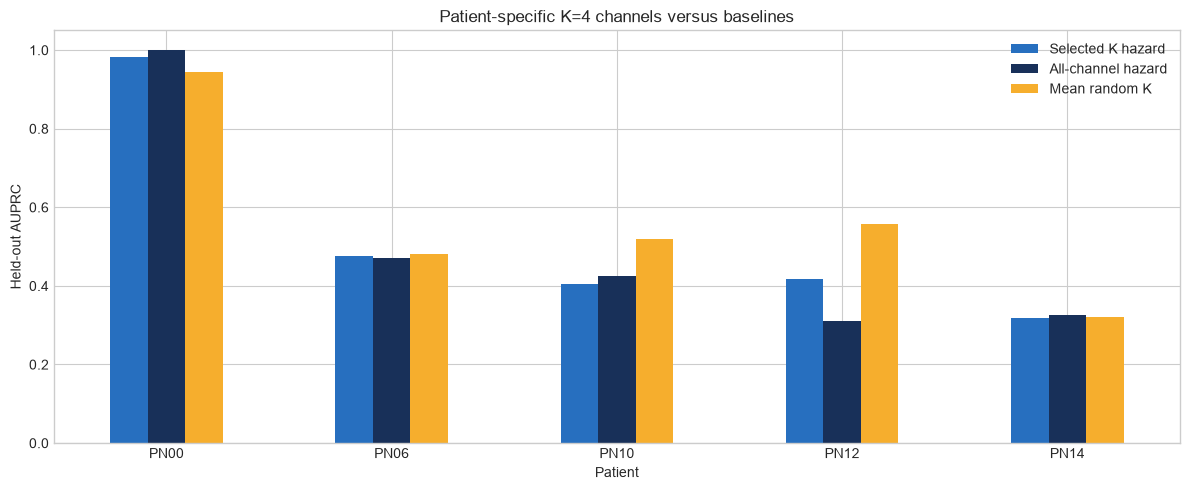

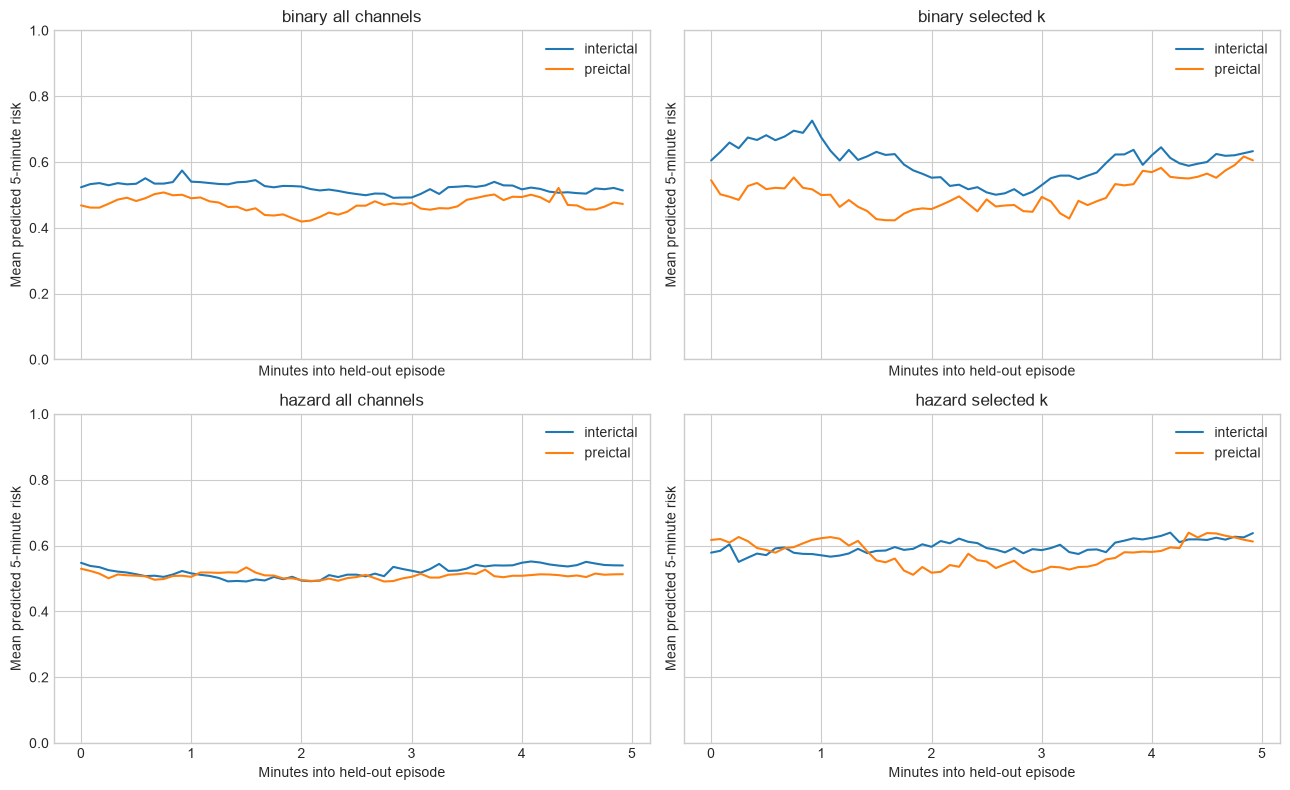

,patient_id,step,action,channel,channels,selection_score,validation_auprc,validation_brier,random_repeat,random_test_auprc,random_test_auroc
0,PN00,1.0,add,F3,F3,0.680676,0.756954,0.305109,NaN,NaN,NaN
1,PN00,2.0,add,FC6,"F3, FC6",0.664054,0.750990,0.347744,NaN,NaN,NaN
2,PN00,3.0,add,FP1,"F3, FC6, FP1",0.606197,0.709641,0.413775,NaN,NaN,NaN
3,PN00,4.0,add,T6,"F3, FC6, FP1, T6",0.694147,0.772713,0.314264,NaN,NaN,NaN
4,PN00,4.0,swap F3 -> FP2,FP2,"FC6, FP1, T6, FP2",0.706233,0.781592,0.301437,NaN,NaN,NaN
5,PN00,NaN,NaN,NaN,"CP1, F10, FP2, O1",NaN,NaN,NaN,1.0,1.000000,1.000000
6,PN00,NaN,NaN,NaN,"CP1, CP6, FC5, FP2",NaN,NaN,NaN,2.0,0.920819,0.881111
7,PN00,NaN,NaN,NaN,"CP2, FC2, FP2, O2",NaN,NaN,NaN,3.0,0.910736,0.872222
8,PN06,1.0,add,CP2,CP2,0.898953,0.933193,0.136959,NaN,NaN,NaN
9,PN06,2.0,add,T3,"CP2, T3",0.832881,0.877441,0.178242,NaN,NaN,NaN


In [5]:
included = summary.loc[summary['status'].eq('included')].copy()
if not included.empty:
    plot_frame = included.set_index('patient_id')[['selected_auprc', 'all_auprc', 'random_k_mean_auprc']]
    ax = plot_frame.plot.bar(figsize=(12, 5), color=['#276FBF', '#183059', '#F6AE2D'])
    ax.set(ylabel='Held-out AUPRC', xlabel='Patient', title=f'Patient-specific K={K} channels versus baselines')
    ax.legend(['Selected K hazard', 'All-channel hazard', 'Mean random K'])
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

if not test_predictions.empty:
    risk_curve = test_predictions.groupby(
        ['model', 'episode_type', 'landmark_step'], as_index=False
    )['event_risk_5m'].mean()
    fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey=True)
    for axis, (model_name, group) in zip(axes.flat, risk_curve.groupby('model')):
        for episode_type, line in group.groupby('episode_type'):
            axis.plot(line['landmark_step'] * 5 / 60, line['event_risk_5m'], label=episode_type)
        axis.set_title(model_name.replace('_', ' '))
        axis.set(xlabel='Minutes into held-out episode', ylabel='Mean predicted 5-minute risk', ylim=(0, 1))
        axis.legend()
    fig.tight_layout()
    plt.show()
display(selection_trace)

## 5. Saved artifacts and interpretation

The notebook saves `patient_channel_summary.csv`, `channel_selection_trace.csv`, `test_landmark_predictions.csv`, and `run_config.json` under `results/personalized_channels/`. Per-patient feature caches are stored under `data/processed/rolling_forecast/personalized_channels/`.

The all-channel comparison uses only channels available in every analyzed recording for that patient, making it a fair deployable baseline. A high held-out score does not establish prospective clinical utility: recordings are short, controls are constructed, alarm rates are unstable, and patients with one test seizure can only have sensitivity 0 or 1.